In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 41.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [46 lines of output]
      /tmp/pip-build-env-k26s8w1a/overlay/lib/python3.10/site-packages/setuptools/dist.py:330: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      running bdist_wheel
      running build
      running build_py
      creating build/lib.linux-x86_64-cpython-310/tokenizers
      copying tokenize

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
import logging
logging.basicConfig(level=logging.ERROR)

from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:
import pandas as pd

dataset_path = "/kaggle/input/final-about-column/final about column upsampled_data.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,Combined,About
0,I am a programmer and I love to solve challeng...,4
1,\nI have worked on the following projects duri...,4
2,More than 10+ experience in developing and int...,4
3,Experienced Software Engineer with a demonstra...,4
4,I am working around 6 years as Software Engine...,4


In [ ]:
# Create the labels based on  score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['About_Label'] = df['About'].apply(map_labels)

print("Mapped About_Label:")
print(df['About_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/About_Label.csv', index=False)


Mapped About_Label:
About_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  About  About_Label
0  I am a programmer and I love to solve challeng...      4            2
1  \nI have worked on the following projects duri...      4            2
2  More than 10+ experience in developing and int...      4            2
3  Experienced Software Engineer with a demonstra...      4            2
4  I am working around 6 years as Software Engine...      4            2


In [ ]:

from transformers import RobertaTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

df = pd.read_csv("/kaggle/working/About_Label.csv")



# Function to tokenize the text using RoBERTa tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'About_Label']].head())


merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0    [input_ids, attention_mask]
1    [input_ids, attention_mask]
2    [input_ids, attention_mask]
3    [input_ids, attention_mask]
4    [input_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  About_Label
0  I am a programmer and I love to solve challeng...            2
1  \nI have worked on the following projects duri...            2
2  More than 10+ experience in developing and int...            2
3  Experienced Software Engineer with a demonstra...            2
4  I am working around 6 years as Software Engine...            2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/About_Label.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")


output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print(f"Files saved to {output_dir}:")
print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
Files saved to /kaggle/working/:
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer

#  Define the custom PyTorch Dataset
class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the combined text and label (Skills_Label) for a specific index
        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['About_Label']


        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)


train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check a batch from the train DataLoader

for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break  # Just to check one batch


Input IDs: tensor([[    0,   100,   524,  ...,     1,     1,     1],
        [    0,  3226,   290,  ..., 34997,  4842,     2],
        [    0, 16587,   230,  ...,     1,     1,     1],
        ...,
        [    0, 37500,    62,  ...,     1,     1,     1],
        [    0, 45752, 24379,  ...,     1,     1,     1],
        [    0, 15952,    10,  ...,     1,     1,     1]])
Attention Mask: tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([0, 2, 0, 2, 0, 1, 2, 1, 1, 2, 1, 0, 1, 0, 0, 1])


In [ ]:
from transformers import DistilBertForSequenceClassification, AdamW
import torch
import torch.nn as nn
from torch.optim import AdamW

# Define the DistilRoBERTa-based model
class DistilRobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(DistilRobertaClass, self).__init__()

        self.distilroberta = DistilBertForSequenceClassification.from_pretrained('distilroberta-base', num_labels=num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through DistilRoBERTa
        output = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        return output.logits

# Initialize the model
model = DistilRobertaClass(num_labels=3)  # I have 3 labels: Negative (0), Neutral (1), Positive (2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the loss function
criterion = nn.CrossEntropyLoss()

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)  # A typical learning rate for fine-tuning DistilRoBERTa
print(model)


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

You are using a model of type roberta to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'transformer.layer.0.attention.k_lin.bias', 'transformer.layer.0.attention.k_lin.weight', 'transformer.layer.0.attention.out_lin.bias', 'transformer.layer.0.attention.out_lin.weight', 'transformer.layer.0.attention.q_lin.bias', 'transformer.layer.0.attention.q_lin.weight', 'transformer.layer.0.attention.v_lin.bias', 'transformer.layer.0.attention.v_lin.weight', 'transformer.layer.0.ffn.lin1.bias', 'transformer.layer.0.ffn.lin1.weight', 'transformer.layer.0.ffn.lin2.bias', 'transformer.layer.0.ffn.lin2.weight', 'transformer.layer.0.output_layer_norm.bias', 'transformer.layer.0.output_layer_norm.weight', 'transformer.la

DistilRobertaClass(
  (distilroberta): DistilBertForSequenceClassification(
    (distilbert): DistilBertModel(
      (embeddings): Embeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (layer): ModuleList(
          (0-5): 6 x TransformerBlock(
            (attention): MultiHeadSelfAttention(
              (dropout): Dropout(p=0.1, inplace=False)
              (q_lin): Linear(in_features=768, out_features=768, bias=True)
              (k_lin): Linear(in_features=768, out_features=768, bias=True)
              (v_lin): Linear(in_features=768, out_features=768, bias=True)
              (out_lin): Linear(in_features=768, out_features=768, bias=True)
            )
            (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
 

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import RobertaTokenizerFast, DistilBertForSequenceClassification, AdamW
import torch.nn as nn
from sklearn.model_selection import train_test_split

# Define the custom Dataset class to handle the text and labels
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



texts = df['Combined'].tolist()
labels = df['About_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)
tokenizer = RobertaTokenizerFast.from_pretrained('distilroberta-base')

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Create dataloaders for batching
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the DistilRoBERTa model class
class DistilRobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(DistilRobertaClass, self).__init__()

        self.distilroberta = DistilBertForSequenceClassification.from_pretrained(
            'distilroberta-base', num_labels=num_labels,
            output_attentions=False, output_hidden_states=False
        )
        # Dropout layer
        self.distilroberta.config.attention_probs_dropout_prob = 0.2

    def forward(self, input_ids, attention_mask):
        output = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits


model = DistilRobertaClass(num_labels=3)  # 3 classes (Negative, Neutral, Positive)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up optimizer
optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training and evaluation loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=10):
    best_val_loss = float('inf')
    patience = 2  # Early stopping patience
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        # Evaluate on validation set
        model.eval()
        correct_val = 0
        total_val = 0
        running_val_loss = 0.0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs  # Logits are returned directly

                loss = criterion(logits, labels)
                running_val_loss += loss.item()

                # Calculate validation accuracy
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0  # Reset counter
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=19)


You are using a model of type roberta to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'transformer.layer.0.attention.k_lin.bias', 'transformer.layer.0.attention.k_lin.weight', 'transformer.layer.0.attention.out_lin.bias', 'transformer.layer.0.attention.out_lin.weight', 'transformer.layer.0.attention.q_lin.bias', 'transformer.layer.0.attention.q_lin.weight', 'transformer.layer.0.attention.v_lin.bias', 'transformer.layer.0.attention.v_lin.weight', 'transformer.layer.0.ffn.lin1.bias', 'transformer.layer.0.ffn.lin1.weight', 'transformer.layer.0.ffn.li

Epoch 1/19
Training Loss: 1.0941, Training Accuracy: 0.3676
Validation Loss: 1.0673, Validation Accuracy: 0.5639
Epoch 2/19
Training Loss: 1.0659, Training Accuracy: 0.4585
Validation Loss: 1.0288, Validation Accuracy: 0.6638
Epoch 3/19
Training Loss: 1.0269, Training Accuracy: 0.5459
Validation Loss: 0.9783, Validation Accuracy: 0.7131
Epoch 4/19
Training Loss: 0.9798, Training Accuracy: 0.5937
Validation Loss: 0.9149, Validation Accuracy: 0.6977
Epoch 5/19
Training Loss: 0.9186, Training Accuracy: 0.6344
Validation Loss: 0.8395, Validation Accuracy: 0.6887
Epoch 6/19
Training Loss: 0.8467, Training Accuracy: 0.6576
Validation Loss: 0.7626, Validation Accuracy: 0.6873
Epoch 7/19
Training Loss: 0.7763, Training Accuracy: 0.6814
Validation Loss: 0.6922, Validation Accuracy: 0.7203
Epoch 8/19
Training Loss: 0.7145, Training Accuracy: 0.6996
Validation Loss: 0.6334, Validation Accuracy: 0.7366
Epoch 9/19
Training Loss: 0.6542, Training Accuracy: 0.7312
Validation Loss: 0.5763, Validation 

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='distilroberta_model.pth', tokenizer_path='distilroberta_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to distilroberta_model.pth
Tokenizer saved to distilroberta_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss, roc_auc_score
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99       727
     Class 1       1.00      0.98      0.99       751
     Class 2       1.00      1.00      1.00       735

    accuracy                           0.99      2213
   macro avg       0.99      0.99      0.99      2213
weighted avg       0.99      0.99      0.99      2213

Hamming Loss: 0.0054


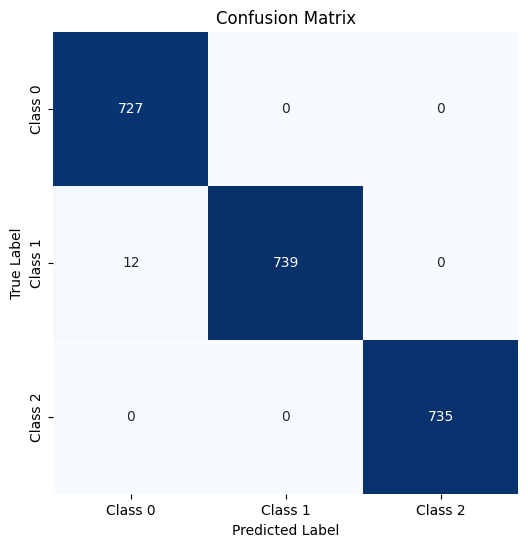

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# Plotting Confusion Matrix
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Class 0","Class 1", "Class 2"], yticklabels=["Class 0","Class 1", "Class 2"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call the evaluate_model function to evaluate the model
evaluate_model(model, val_dataloader, device)


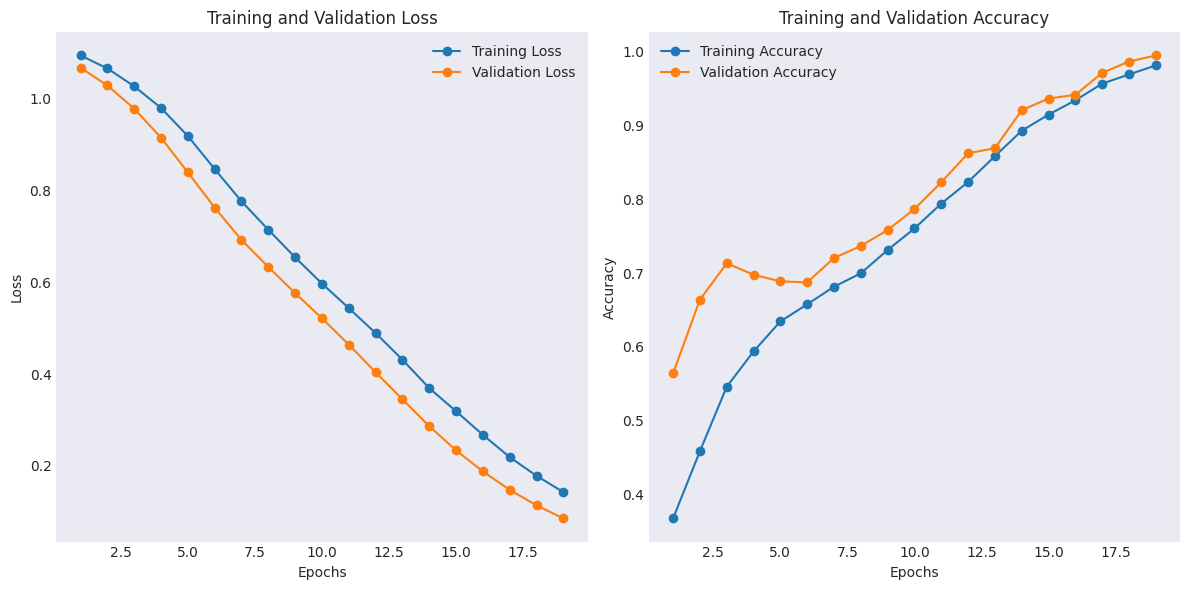

In [ ]:
import matplotlib.pyplot as plt

# Data for 19 epochs
epochs = list(range(1, 20))
train_loss = [
    1.0941, 1.0659, 1.0269, 0.9798, 0.9186, 0.8467, 0.7763, 0.7145, 0.6542, 0.5972,
    0.5437, 0.4893, 0.4313, 0.3693, 0.3189, 0.2675, 0.2189, 0.1783, 0.1427
]
train_accuracy = [
    0.3676, 0.4585, 0.5459, 0.5937, 0.6344, 0.6576, 0.6814, 0.6996, 0.7312, 0.7603,
    0.7940, 0.8233, 0.8582, 0.8927, 0.9145, 0.9339, 0.9565, 0.9689, 0.9812
]
val_loss = [
    1.0673, 1.0288, 0.9783, 0.9149, 0.8395, 0.7626, 0.6922, 0.6334, 0.5763, 0.5214,
    0.4643, 0.4038, 0.3450, 0.2864, 0.2338, 0.1878, 0.1477, 0.1138, 0.0854
]
val_accuracy = [
    0.5639, 0.6638, 0.7131, 0.6977, 0.6887, 0.6873, 0.7203, 0.7366, 0.7582, 0.7867,
    0.8229, 0.8622, 0.8690, 0.9205, 0.9363, 0.9413, 0.9711, 0.9864, 0.9946
]

# Set figure background color to white and remove the black border
plt.figure(figsize=(12, 6), facecolor='white')

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)  # Remove grid

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()
